<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_390304/1094808130.py:41: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Daily Mortality Rate ($\mu_{adult}$)')
/tmp/ipykernel_390304/1094808130.py:47: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(days, cumulative_cold_stress, color='midnightblue', lw=2.5, label='Cumulative Index ($\mu_{cold}$)')


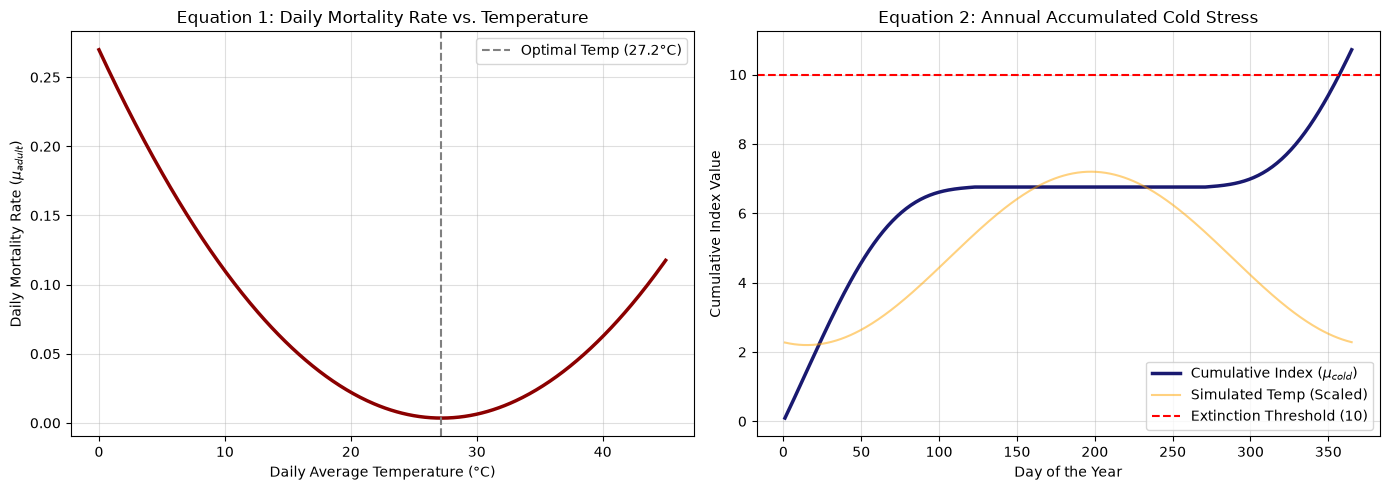

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Equation 1: Daily Mortality Rate (\mu_adult)
# ==========================================
def mu_adult(T):
    # Mortality equation (bounded to a maximum of 1.0, or 100% mortality)
    mortality = 0.00036 * (T - 27.2)**2 + 0.0035
    return np.clip(mortality, 0, 1)

# Generate temperatures from 0 to 45 degrees C
temperatures = np.linspace(0, 45, 500)
mortality_rates = mu_adult(temperatures)

# ==========================================
# Equation 2: Cumulative Cold Stress (\mu_cold)
# ==========================================
# Simulate a year of temperatures for a moderate climate: 
# (Dips to ~5°C in winter, peaks at ~30°C in summer)
days = np.arange(1, 366)
yearly_temps = 23.5 - 12.5 * np.cos(2 * np.pi * (days - 15) / 365) 

# Calculate daily cold stress (only applied on days where T <= 27.2)
daily_cold_stress = np.where(yearly_temps <= 27.2, mu_adult(yearly_temps), 0)

# Accumulate the cold stress over the 365 days
cumulative_cold_stress = np.cumsum(daily_cold_stress)

# ==========================================
# Plotting the Graphs
# ==========================================
plt.figure(figsize=(14, 5))

# Graph 1
plt.subplot(1, 2, 1)
plt.plot(temperatures, mortality_rates, color='darkred', lw=2.5)
plt.axvline(x=27.2, color='gray', linestyle='--', label='Optimal Temp (27.2°C)')
plt.title('Equation 1: Daily Mortality Rate vs. Temperature')
plt.xlabel('Daily Average Temperature (°C)')
plt.ylabel('Daily Mortality Rate ($\mu_{adult}$)')
plt.grid(True, alpha=0.4)
plt.legend()

# Graph 2
plt.subplot(1, 2, 2)
plt.plot(days, cumulative_cold_stress, color='midnightblue', lw=2.5, label='Cumulative Index ($\mu_{cold}$)')
plt.plot(days, yearly_temps / 5, color='orange', alpha=0.5, label='Simulated Temp (Scaled)')
plt.axhline(y=10, color='red', linestyle='--', label='Extinction Threshold (10)')
plt.title('Equation 2: Annual Accumulated Cold Stress')
plt.xlabel('Day of the Year')
plt.ylabel('Cumulative Index Value')
plt.grid(True, alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()


Processing Year: 2021
--> Loading cached 2021 data from disk for Texas...

Processing Year: 2022
--> Loading cached 2022 data from disk for Texas...

Processing Year: 2023
--> Loading cached 2023 data from disk for Texas...

Processing Year: 2024
--> Loading cached 2024 data from disk for Texas...

Processing Year: 2025
--> Loading cached 2025 data from disk for Texas...


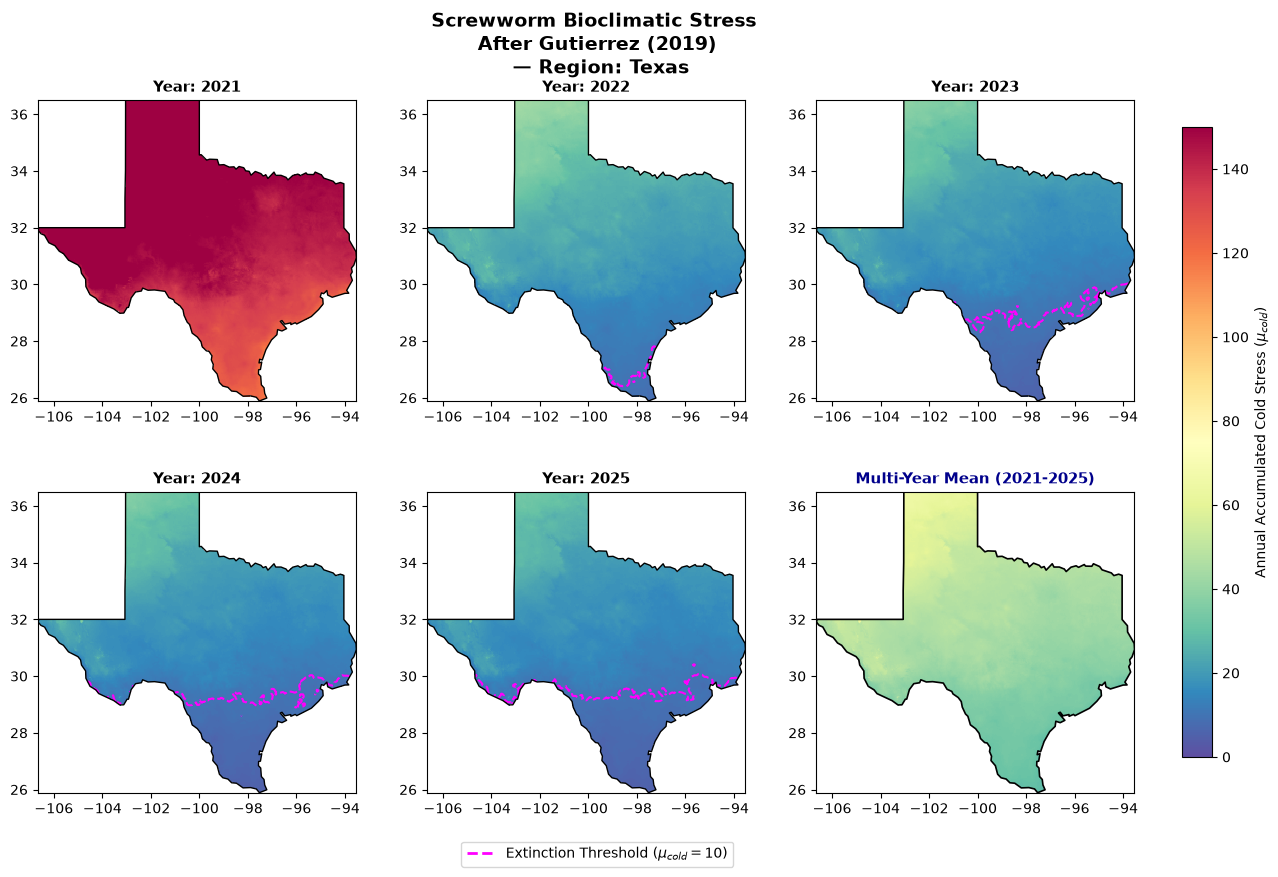

In [1]:
import os
import json
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
from shapely.geometry import mapping
import matplotlib.lines as mlines

def check_cache_validity(cache_meta_path, current_bbox):
    """
    Checks if cached spatial metadata exists and matches the requested bounding box.
    """
    if not os.path.exists(cache_meta_path):
        return False
    try:
        with open(cache_meta_path, 'r') as f:
            cached_meta = json.load(f)
        # Compare current bounding box floats against cache with tolerance
        return np.allclose(cached_meta['bbox'], list(current_bbox), rtol=1e-5)
    except Exception:
        return False

def save_cache_metadata(cache_meta_path, current_bbox, region_name):
    """
    Saves bounding box and region name headers as a tracking JSON sidecar.
    """
    meta = {
        'region_name': region_name,
        'bbox': list(current_bbox)
    }
    with open(cache_meta_path, 'w') as f:
        json.dump(meta, f, indent=4)

def get_gridmet_data(year, bbox=None, cache_dir='gridmet_cache', region_name='region'):
    """
    Downloads or pulls from disk a spatial slice of GridMET min/max temperatures.
    """
    os.makedirs(cache_dir, exist_ok=True)
    tmmx_cache = os.path.join(cache_dir, f"gridmet_tmmx_{year}.nc")
    tmmn_cache = os.path.join(cache_dir, f"gridmet_tmmn_{year}.nc")
    meta_cache = os.path.join(cache_dir, "spatial_metadata.json")
    
    is_cache_valid = check_cache_validity(meta_cache, bbox) if bbox is not None else False
    
    if is_cache_valid and os.path.exists(tmmx_cache) and os.path.exists(tmmn_cache):
        print(f"--> Loading cached {year} data from disk for {region_name}...")
        tmmx = xr.open_dataarray(tmmx_cache).load()
        tmmn = xr.open_dataarray(tmmn_cache).load()
    else:
        print(f"--> Connecting to remote OpenDAP for year {year} (New subset or bounding box mismatch)...")
        tmmx_url = f"http://thredds.northwestknowledge.net:8080/thredds/dodsC/MET/tmmx/tmmx_{year}.nc"
        tmmn_url = f"http://thredds.northwestknowledge.net:8080/thredds/dodsC/MET/tmmn/tmmn_{year}.nc"
        
        ds_max = xr.open_dataset(tmmx_url)
        ds_min = xr.open_dataset(tmmn_url)
        
        if bbox is not None:
            lon_min, lat_min, lon_max, lat_max = bbox
            # Fixed latitude slice tracking decreasing index values in gridmet
            lat_slice = slice(lat_max, lat_min)
            lon_slice = slice(lon_min, lon_max)
            
            tmmx = ds_max['air_temperature'].sel(lat=lat_slice, lon=lon_slice).load()
            tmmn = ds_min['air_temperature'].sel(lat=lat_slice, lon=lon_slice).load()
        else:
            tmmx = ds_max['air_temperature'].load()
            tmmn = ds_min['air_temperature'].load()
            
        # Cache local raw chunks to disk
        tmmx.to_netcdf(tmmx_cache)
        tmmn.to_netcdf(tmmn_cache)
        if bbox is not None:
            save_cache_metadata(meta_cache, bbox, region_name)
            
    return tmmx, tmmn

def calculate_screwworm_cold_stress(tmmx, tmmn):
    """
    Applies the Gutierrez (2019) model to compute annual accumulated cold stress.
    """
    # Kelvin to Celsius conversion
    t_mean_celsius = ((tmmx + tmmn) / 2.0) - 273.15
    
    # Equation 1: Daily quadratic mortality limit
    mu_daily = 0.00036 * (t_mean_celsius - 27.2)**2 + 0.0035
    mu_daily = xr.where(mu_daily > 1.0, 1.0, mu_daily)
    mu_daily = xr.where(mu_daily < 0.0, 0.0, mu_daily)
    
    # Equation 2: Filter and aggregate index values for cold days (<= 27.2)
    # Checking for 'day' dimension standard in GridMET, falling back to 'time'
    time_dim = 'day' if 'day' in t_mean_celsius.dims else 'time'
    cold_stress_daily = xr.where(t_mean_celsius <= 27.2, mu_daily, 0.0)
    
    return cold_stress_daily.sum(dim=time_dim)

def process_and_plot_phenology(years, region_gdf, region_name="Texas"):
    """
    Processes multiple years, generates historical metrics, and renders a grid 
    consisting of each individual year alongside the long-term baseline average.
    """
    bbox = region_gdf.total_bounds
    annual_results = {}
    
    # Step 1: Sequential data harvesting & math processing
    for y in years:
        print(f"\nProcessing Year: {y}")
        tmmx, tmmn = get_gridmet_data(year=y, bbox=bbox, region_name=region_name)
        stress_map = calculate_screwworm_cold_stress(tmmx, tmmn)
        
        # Inject metadata and clip geospatially to outline
        stress_map = stress_map.rio.write_crs("EPSG:4326")
        stress_map = stress_map.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        clipped = stress_map.rio.clip(region_gdf.geometry.apply(mapping), region_gdf.crs, drop=True)
        annual_results[y] = clipped

    # Step 2: Combine arrays to calculate multi-year ensemble average
    combined_years = xr.concat(list(annual_results.values()), dim='year')
    historical_avg = combined_years.mean(dim='year')
    
    # Step 3: Compute plot layout dynamically (Individual Years + 1 for Average Panel)
    num_plots = len(years) + 1
    ncols = 3 if num_plots >= 3 else num_plots
    nrows = int(np.ceil(num_plots / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    
    plot_idx = 0
    # Render individual yearly indices
    for y in years:
        ax = axes_flat[plot_idx]
        data = annual_results[y]
        im = data.plot(ax=ax, cmap='Spectral_r', vmin=0, vmax=150, add_colorbar=False, zorder=1)
        region_gdf.boundary.plot(ax=ax, color='black', linewidth=1.0, zorder=3)
        
        # Add 10.0 extinction threshold isoline
        try:
            data.plot.contour(ax=ax, levels=[10.0], colors=['magenta'], linewidths=[1.5], linestyles=['--'], zorder=2)
        except Exception:
            pass
            
        ax.set_title(f"Year: {y}", fontsize=11, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("")
        plot_idx += 1
        
    # Render historical ensemble average panel
    ax_avg = axes_flat[plot_idx]
    im_avg = historical_avg.plot(ax=ax_avg, cmap='Spectral_r', vmin=0, vmax=150, add_colorbar=False, zorder=1)
    region_gdf.boundary.plot(ax=ax_avg, color='black', linewidth=1.2, zorder=3)
    try:
        historical_avg.plot.contour(ax=ax_avg, levels=[10.0], colors=['magenta'], linewidths=[2.0], linestyles=['--'], zorder=2)
    except Exception:
        pass
    ax_avg.set_title(f"Multi-Year Mean ({years[0]}-{years[-1]})", fontsize=11, fontweight='bold', color='darkblue')
    ax_avg.set_xlabel("")
    ax_avg.set_ylabel("")
    plot_idx += 1
    
    # Turn off any remaining blank subplots
    for i in range(plot_idx, len(axes_flat)):
        fig.delaxes(axes_flat[i])
        
    # Standardize global layouts and single colorbar asset
    fig.subplots_adjust(right=0.86, hspace=0.3, wspace=0.2)
    cbar_ax = fig.add_axes([0.89, 0.15, 0.02, 0.7])
    fig.colorbar(im_avg, cax=cbar_ax, label='Annual Accumulated Cold Stress ($\\mu_{cold}$)')
    
    # Global legend positioning
    legend_line = mlines.Line2D([], [], color='magenta', linestyle='--', linewidth=2, label='Extinction Threshold ($\\mu_{cold} = 10$)')
    fig.legend(handles=[legend_line], loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=1, frameon=True)
    
    fig.suptitle(f"Screwworm Bioclimatic Stress \n After Gutierrez (2019) \n — Region: {region_name}", fontsize=14, fontweight='bold', y=0.98)
    plt.savefig(f"outputs/screwworm_stress_{region_name}_{years[0]}-{years[-1]} coldscaled.png", dpi=300, bbox_inches='tight')

    plt.show()
    #save plot to outputs

# ==========================================
# Example Generic Execution Pipeline
# ==========================================
if __name__ == "__main__":
    # Fetch geographic region layout (using the previous Texas profile as sample)
    states_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
    us_states = gpd.read_file(states_url)
    target_region = us_states[us_states['name'] == 'Texas'].to_crs(epsg=4326)
    
    # Target year array to evaluate
    analysis_years = [2021, 2022, 2023, 2024, 2025]
    
    # Execute structural pipeline
    process_and_plot_phenology(years=analysis_years, region_gdf=target_region, region_name="Texas")